<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.6}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumno:} & Jiménez Rivera Emiliano Kaleb \\[6pt]
\textbf{Fecha de realización:} & 27/09/2026
\end{array}

</center>

#Parte 2: Convolución

Dada la imagen I = [[1,2,0],[0,1,3],[2,1,0]]

Y el kernel K = [[1,0],[-1,1]]

Aplicar convolución 2D sin padding y stride 1.

Preguntas:

- ¿Qué cambia si se agrega padding?
- ¿Cómo impacta el tamaño del kernel en el costo computacional?


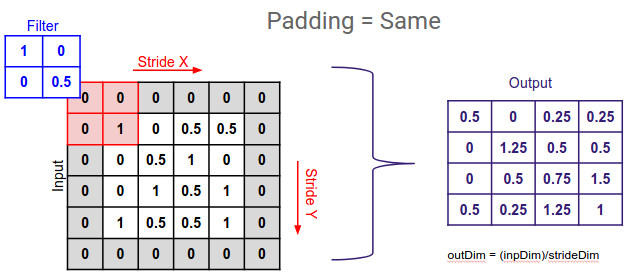

In [ ]:
import numpy as np

# Definimos la imagen I y el kernel K
I = np.array([[1, 2, 0],
              [0, 1, 3],
              [2, 1, 0]])

K = np.array([[1, 0],
              [-1, 1]])

def convolution2d(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Sin padding y stride 1, el tamaño de salida es (N - K + 1)
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Extraemos la región de interés (ventana)
            region = image[i:i+ker_h, j:j+ker_w]
            # Multiplicación elemento a elemento y suma
            output[i, j] = np.sum(region * kernel)

    return output

resultado = convolution2d(I, K)
print("Resultado de la convolución:")
print(resultado)

Resultado de la convolución:
[[ 2.  4.]
 [-1.  0.]]


**¿Qué cambia si se agrega padding?**

El padding (relleno de ceros en los bordes) tiene dos efectos principales:

Mantiene el tamaño: Sin padding, la imagen se encoge en cada capa de convolución. Con el padding adecuado, la salida tiene las mismas dimensiones que la entrada ($3 \times 3$ en tu caso).

Información de los bordes: Sin padding, los píxeles de las esquinas solo se procesan una vez, mientras que los centrales participan en múltiples ventanas. El padding permite que la red "aproveche" mejor la información de los bordes.

**¿Cómo impacta el tamaño del kernel en el costo computacional?**

El impacto es cuadrático.Si tienes un kernel de $k \times k$, por cada píxel de salida realizas $k^2$ multiplicaciones y sumas.

Si duplicas el tamaño del kernel (de $3 \times 3$ a $6 \times 6$), el costo computacional no se duplica, sino que se cuadruplica (pasas de 9 a 36 operaciones por paso).

En modelos grandes, esto puede ralentizar significativamente el entrenamiento, por lo que a menudo se prefieren varios kernels pequeños (como $3 \times 3$) apilados en lugar de uno muy grande.

**Cálculo Manual (para verificar)**

Si quieres comprobar el código, el resultado debería ser:

Posición (0,0): $(1 \times 1) + (2 \times 0) + (0 \times -1) + (1 \times 1) = 2$

Posición (0,1): $(2 \times 1) + (0 \times 0) + (1 \times -1) + (3 \times 1) = 4$

Posición (1,0): $(0 \times 1) + (1 \times 0) + (2 \times -1) + (1 \times 1) = -1$

Posición (1,1): $(1 \times 1) + (3 \times 0) + (1 \times -1) + (0 \times 1) = 0$


Resultado Final:$$\begin{bmatrix} 2 & 4 \\ -1 & 0 \end{bmatrix}$$

# **Ejercicio Adicional: Multiplicación de matrices de tamaño nxn**

Crear una función que reciba el tamaño de la matriz n y muestre el resultado de la multiplicación. Para eso se recomienda crear matrices cuadradas de tamaño 10×10, 100×100, 1000×1000 y 10000 x10000, o hasta donde el poder de su computadora lo soporte. Llenarlas con numero aleatorios del 0 al 99 y que sirva como base para implementar una función de multiplicación de matrices. Ejecutar la multiplicación y mostrar resultados (parcialmente para tamaños grandes) del tamaño que se indique.


In [ ]:
import random
import time
def crear_matriz(n: int):
    """Crea una matriz nxn con enteros aleatorios desde el 0 hasta el 99."""
    return [[random.randint(0, 99) for _ in range(n)] for _ in range(n)]

def multiplicar(A, B):
    m = len(A)
    n1 = len(A[0])
    n2 = len(B)
    p = len(B[0])

    if n1 != n2:
        raise Exception("Las matrices no se pueden multiplicar")

    # Transpuesta de B: si B es n2 x p, B_T será p x n2
    B_T = [[0 for _ in range(n2)] for _ in range(p)]

    for i in range(n2):
        filaB = B[i]
        for j in range(p):
            B_T[j][i] = filaB[j]

    result = [[0 for _ in range(p)] for _ in range(m)]

    for i in range(m):
        filaA = A[i]
        for j in range(p):
            columnaB = B_T[j]
            s = 0
            for k in range(n1):
                s += filaA[k] * columnaB[k]
            result[i][j] = s

    return result

def imprimir_matriz(M):
    for fila in M:
        print(fila)


def multiplicacion(n: int):
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n debe ser un entero positivo")

    print(f"\nCreando matrices {n}x{n} con valores aleatorios 0..99...")
    A = crear_matriz(n)
    B = crear_matriz(n)

    print("Imprimiendo matriz A")
    imprimir_matriz(A)
    print("Imprimiendo matriz B")
    imprimir_matriz(B)


    print("\nMultiplicando matriz completa")
    t2 = time.time()
    C = multiplicar(A, B)
    t3 = time.time()
    print(f"Tiempo multiplicación completa: {t3 - t2:.4f} s")

    imprimir_matriz(C)




if __name__ == "__main__":
    #Caso completo: O(n³)
    try:
        n = int(input("Ingrese el tamaño n de la matriz (matriz cuadrada): "))
        multiplicacion(n)
    except ValueError as e:
        print(f"Error: {e}")

Ingrese el tamaño n de la matriz (matriz cuadrada): 100

Creando matrices 100x100 con valores aleatorios 0..99...
Imprimiendo matriz A
[71, 74, 97, 18, 29, 91, 99, 36, 69, 32, 89, 93, 98, 39, 60, 88, 66, 94, 88, 97, 78, 57, 85, 23, 28, 34, 3, 77, 3, 92, 44, 55, 13, 76, 95, 88, 40, 13, 16, 97, 54, 49, 27, 78, 61, 27, 78, 29, 68, 77, 6, 61, 32, 11, 28, 39, 58, 39, 24, 45, 61, 81, 52, 53, 47, 92, 28, 6, 72, 21, 28, 41, 42, 84, 89, 4, 39, 11, 96, 63, 68, 6, 22, 69, 95, 67, 26, 55, 18, 52, 31, 94, 65, 54, 79, 67, 51, 16, 39, 90]
[16, 42, 99, 58, 38, 76, 39, 60, 53, 35, 14, 51, 73, 6, 47, 21, 84, 56, 16, 52, 9, 46, 53, 82, 5, 26, 0, 45, 16, 80, 54, 53, 52, 33, 22, 31, 82, 17, 26, 95, 14, 42, 13, 33, 26, 55, 61, 89, 81, 4, 13, 54, 7, 32, 88, 51, 54, 20, 4, 27, 3, 21, 22, 18, 93, 78, 68, 45, 18, 94, 5, 54, 78, 38, 36, 30, 14, 95, 0, 74, 96, 50, 23, 27, 23, 69, 30, 93, 12, 57, 96, 80, 75, 64, 64, 65, 13, 6, 50, 56]
[73, 39, 63, 56, 23, 23, 21, 63, 82, 91, 36, 0, 47, 63, 13, 3, 94, 2, 68, 21, 60

#Conclusiones finales del estudiante

En esta práctica pudimos trabajr con las operacioens fundamentales para redes neuronales: las convoluciones 2d y la multplicación de matrices. Usamos algunas funciones de la biblioteca de numpy como convolution2d, usando una matriz kernel y matrices sobre una imagen nos ayudó a ver que es padding y stride. Vimos que por ejemplo el costo de cada paso puede crecer de forma cuadrática con el tamaño del kernel y es por esto que usamos y en general se prefieren kernels pequeños. Otra cosa importante que se hizo fue el uso de la transpuesta para eficientar las operaciones matriciales. En general, esta práctica nos dejó claro por qué bibliotecas como Numpy, que delegan las operaciones a procesos optimizados en c, y el uso de las GPUs son primordiales en algoritmos de IA. Pues entrenar una red convolucional implica repetir millones de multiplicaciones y con una implementación no tan optimizada como esta se vio claramente que no es posible siquiera crear matrices de dimensión 100000 en mi Mac con una gráfica de gama media; esto se debió más que nada al timeout de colab y que después de 10 minutos no se terminaran de procesar las generaciones de matrices. Ya con dimensión 10000 apenas se pudieron construir las matrices en aproximadamente 7 minutos, después las operaciones no se pudieron realizar por la misma razón que en el primer caso, además de que no pensaba que fuera a terminar después de 30 minutos esperando. Fue un impacto muy grande ver que se tardara tanto en solo multiplicar matrices

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>